# CREACIÓN DE RED NEURONAL PARA GENERAR EMBEDDINGS CON TENSORFLOW

# paso 1 - importamos librerias

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# paso 2 - Dataset de ejemplo

In [2]:
sentences = [
    "I love deep learning",
    "I love machine learning",
    "deep learning is fun"
]

# paso 3 - Tokenizar las frases (convertir las palabras a índices)

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

# paso 4 - creamos el vocabulario

In [4]:
vocab_size = len(tokenizer.word_index) + 1  # Añadimos 1 para considerar el índice 0 (pad)
print("Vocabulary size:", vocab_size)
tokenizer.word_index

Vocabulary size: 8


{'learning': 1, 'i': 2, 'love': 3, 'deep': 4, 'machine': 5, 'is': 6, 'fun': 7}

## paso 5 - Convertir las frases a secuencias de índices

In [5]:
sequences = tokenizer.texts_to_sequences(sentences)

# Pad sequences para asegurar que todas las secuencias tengan la misma longitud

In [6]:
max_length = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

print("Padded sequences:", padded_sequences)

Padded sequences: [[2 3 4 1]
 [2 3 5 1]
 [4 1 6 7]]


# CREAMOS EL MODELO DE RED NEURONAL PARA EMBEDDING

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAveragePooling1D

In [8]:
# Definir el modelo
embedding_dim = 8  # Dimensión de los embeddings (cada palabra será representada por un vector de 8 números)

model = Sequential()

# Capa de Embeddings
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))

# Capa de GlobalAveragePooling1D para hacer un resumen de la secuencia
model.add(GlobalAveragePooling1D())

# Capa densa para clasificación (en este caso, un ejemplo de regresión)
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Resumen del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# ENTRENAMOS EL MODELO

In [10]:
# Etiquetas de ejemplo para clasificación binaria (por ejemplo, 0 o 1)
labels = [1, 0, 1]  # Aquí se podría tener una etiqueta binaria para cada frase

# Convertir las etiquetas en un tensor
labels_tensor = tf.convert_to_tensor(labels)

# Entrenar el modelo
model.fit(padded_sequences, labels_tensor, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 0.6988
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3333 - loss: 0.6976
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3333 - loss: 0.6964
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3333 - loss: 0.6952
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6667 - loss: 0.6940


In [11]:
# Obtener los embeddings aprendidos por la capa
embeddings = model.layers[0].get_weights()[0]
print("Embeddings learned by the model:")
print(embeddings)

Embeddings learned by the model:
[[-0.00378417 -0.04973979 -0.04044006  0.02980354  0.04935869 -0.01652558
   0.03601689 -0.03877212]
 [-0.00269833 -0.02272112  0.02518145  0.01574273 -0.00834054 -0.00864417
  -0.01610712  0.03581914]
 [-0.0443604   0.03052128  0.01379413  0.03764456 -0.00698013 -0.01865675
   0.00018524 -0.0293927 ]
 [ 0.03344961  0.03998172 -0.04960544 -0.01267335  0.04043067  0.01835112
   0.04359838  0.03225482]
 [-0.02348242 -0.0307627   0.01878457  0.01505478  0.03122455 -0.01090289
  -0.02077826 -0.01520721]
 [ 0.00279724  0.02255522  0.03629031  0.0138878  -0.0402917   0.00682839
  -0.02268283 -0.0402193 ]
 [ 0.02780258 -0.0040178   0.02553816  0.03035237  0.01962369 -0.02405135
  -0.04066508  0.04712236]
 [ 0.03851005  0.01534917 -0.00988824 -0.02471737 -0.00063419 -0.0265024
  -0.04473213 -0.03985764]]


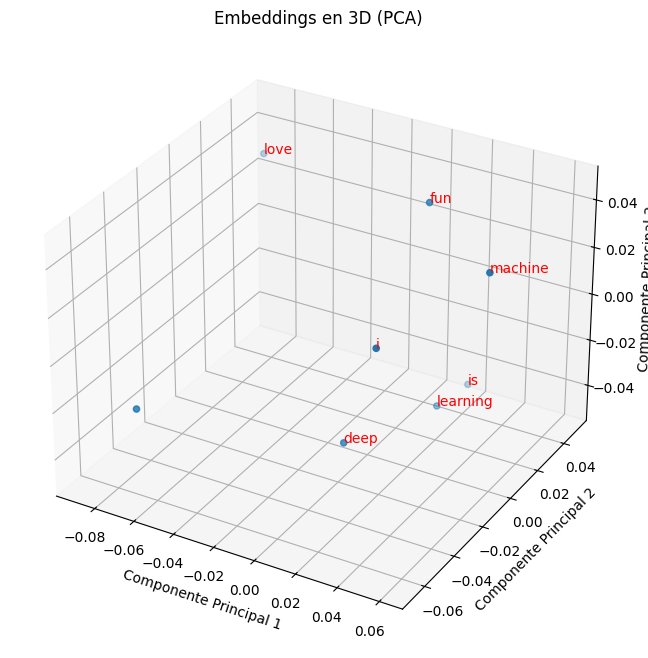

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# Aplicar PCA para reducir la dimensionalidad a 3 componentes
pca = PCA(n_components=3)
embeddings_3d = pca.fit_transform(embeddings)

# Crear la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotear los embeddings en 3D
ax.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2])

# Añadir etiquetas para cada punto (palabra)
words = list(tokenizer.word_index.keys())
for i, word in enumerate(words):
    ax.text(embeddings_3d[i+1, 0], embeddings_3d[i+1, 1], embeddings_3d[i+1, 2], word, color='red')

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.set_title('Embeddings en 3D (PCA)')

plt.show()